# Week 1 — First Look: NHANES & Scalar Least Squares

*INFO 521 worked notebook (Module 1). Companion to lectures m1a/m1b — read along, or run it
yourself: it needs the course environment (the `info521` package from Unit 0's setup).*

One clinical question drives the whole term: **what predicts systolic blood pressure?**
Here we load the course dataset, look at it, and fit our first model — a straight line —
by least squares, from scratch.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from info521.data import load_clinical, primary_predictor

# Okabe-Ito colorblind-safe palette (course standard)
BLUE, VERMILLION, GREEN = "#0072B2", "#D55E00", "#009E73"
rng = np.random.default_rng(521)   # course seed policy: 521, always

ds = load_clinical()
print("patients:", len(ds["y"]), "| features:", ds["features"])
print("target:", ds["target"], "| primary predictor:", ds["primary"])

patients: 5102 | features: ['age', 'bmi', 'waist', 'chol', 'hdl', 'hba1c']
target: sbp | primary predictor: age


The loader returns plain NumPy arrays — *you* build the design matrices. Note what is
**not** in the features: diastolic BP is reserved (it co-measures the label's physiology —
the leakage rule from lecture m1a).

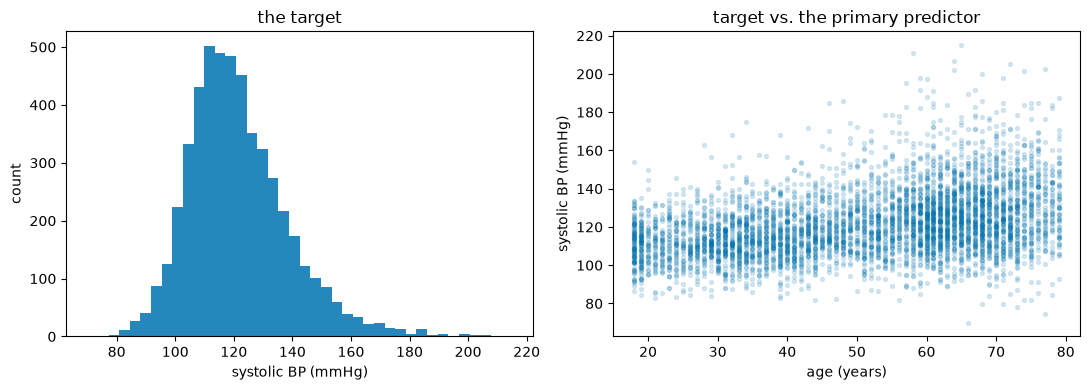

In [2]:
age = primary_predictor(ds)        # years
sbp = ds["y"]                      # systolic BP, mmHg

fig, (axL, axR) = plt.subplots(1, 2, figsize=(11, 4))
axL.hist(sbp, bins=40, color=BLUE, alpha=0.85)
axL.set_xlabel("systolic BP (mmHg)"); axL.set_ylabel("count")
axL.set_title("the target")
axR.scatter(age, sbp, s=8, alpha=0.15, color=BLUE)
axR.set_xlabel("age (years)"); axR.set_ylabel("systolic BP (mmHg)")
axR.set_title("target vs. the primary predictor")
plt.tight_layout(); plt.show()

## Standardize the predictor

Standardizing age ($z = (x - \bar{x})/s_x$) makes the intercept interpretable (prediction
at *average* age) and puts the slope in per-SD units.

In [3]:
age_mean, age_sd = age.mean(), age.std()
z = (age - age_mean) / age_sd
print(f"mean age = {age_mean:.1f} yr, SD = {age_sd:.1f} yr")

mean age = 51.1 yr, SD = 17.3 yr


## Fit by least squares — the normal equations

Model $\hat{y} = w_0 + w_1 z$, loss $\mathcal{L}(\mathbf{w}) = \frac{1}{N}\lVert\mathbf{y}-\mathbf{X}\mathbf{w}\rVert_2^2$.
Setting $\nabla\mathcal{L} = \mathbf{0}$ gives $\mathbf{X}^\top\mathbf{X}\,\hat{\mathbf{w}} = \mathbf{X}^\top\mathbf{y}$
(lecture m1b). We *solve* the system rather than form the inverse.

In [4]:
X = np.column_stack([np.ones_like(z), z])       # intercept + standardized age
w_hat = np.linalg.solve(X.T @ X, X.T @ sbp)     # ŵ = (XᵀX)⁻¹Xᵀy, computed stably
print(f"ŵ0 = {w_hat[0]:.2f} mmHg   ŵ1 = {w_hat[1]:.2f} mmHg per SD of age")
print(f"   → {w_hat[1]/age_sd:.3f} mmHg per YEAR of age")

ŵ0 = 121.49 mmHg   ŵ1 = 6.48 mmHg per SD of age
   → 0.375 mmHg per YEAR of age


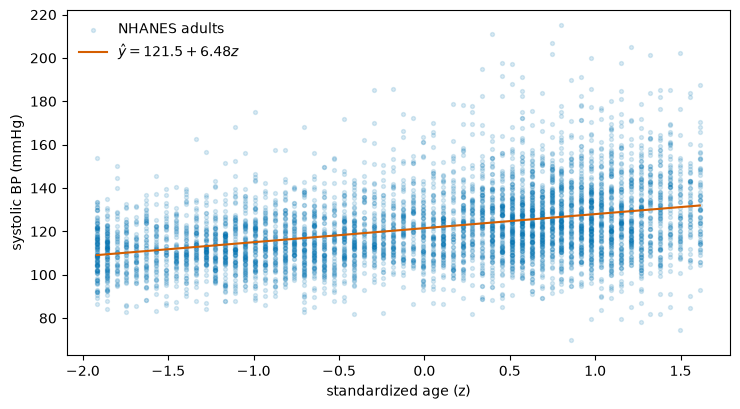

In [5]:
grid = np.linspace(z.min(), z.max(), 200)
fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.scatter(z, sbp, s=8, alpha=0.15, color=BLUE, label="NHANES adults")
ax.plot(grid, w_hat[0] + w_hat[1] * grid, color=VERMILLION,
        label=f"$\\hat{{y}} = {w_hat[0]:.1f} + {w_hat[1]:.2f}z$")
ax.set_xlabel("standardized age (z)"); ax.set_ylabel("systolic BP (mmHg)")
ax.legend(frameon=False); plt.tight_layout(); plt.show()

## Interpret — always in clinical units

In [6]:
resid = sbp - X @ w_hat
print(f"predicted SBP at average age : {w_hat[0]:.1f} mmHg")
print(f"one SD of age (~{age_sd:.0f} yr)   : +{w_hat[1]:.1f} mmHg")
print(f"typical miss (RMS residual)  : {np.sqrt((resid**2).mean()):.1f} mmHg")

predicted SBP at average age : 121.5 mmHg
one SD of age (~17 yr)   : +6.5 mmHg
typical miss (RMS residual)  : 15.9 mmHg


The line explains the *trend*, not the person: predictions carry ±16 mmHg of patient-level
scatter. Where that number comes from — and what it really is — is Module 3's story.

**Try it yourself:** refit on a random subsample of 100 patients
(`rng.choice(len(sbp), 100, replace=False)`). How much do $\hat{w}_0, \hat{w}_1$ move?
That wobble is *parameter uncertainty* — Module 3 gives it a formula.